<a href="https://colab.research.google.com/github/digitalchessman-tech/data-science-ipython-notebooks/blob/master/Ejemplo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejemplo de regresión múltiple usando dataset Boston Housing.

In [6]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
data = pd.read_csv("HousingData.csv")
# información del dataset
# print(data.DESCR) # Removed as DataFrame objects do not have a .DESCR attribute
print('Información general del DataFrame:')
data.info()
print('\nDescripción estadística de las columnas numéricas:')
print(data.describe())

# Variables independientes (entradas)
# Assuming 'MEDV' is the target variable, drop it to get independent variables
df = data.drop('MEDV', axis=1)

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB

Descripción estadística de las columnas numéricas:
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  486.000000  486.000000  486.000000  486.000000  506.000000  

Usaremos todas las variables para construir el modelo:

In [9]:
# Variable de salida
y = data['MEDV']

# Modelo con todas las variables
X = df

# Train /test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

<Axes: >

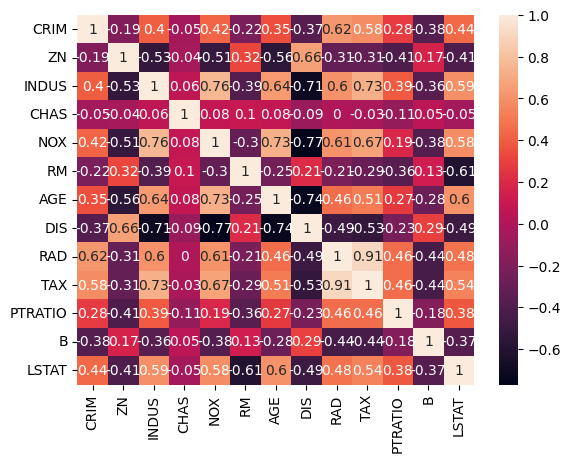

In [10]:
# Correlación para todos los datos
import seaborn as sns
correlation_matrix = df.corr().round(2)
sns.heatmap(data=correlation_matrix, annot=True)


Se aprecia como las variables NOX y DIS tienen alta correlación (0.77), por lo que nmo sería necesario que ambas aparezcan en el modelo.

In [14]:
# Handle missing values in X and y before fitting the model
# It's crucial to align X and y after dropping NaNs
# Create a temporary DataFrame by concatenating X and y to drop rows with any NaNs consistently
temp_df = pd.concat([X, y], axis=1)
temp_df_cleaned = temp_df.dropna()

X_cleaned = temp_df_cleaned.drop(columns=['MEDV']) # Assuming 'MEDV' is the target column name
y_cleaned = temp_df_cleaned['MEDV']

# Add a constant to the independent variables for the OLS model
X_cleaned = sm.add_constant(X_cleaned)

model = sm.OLS(y_cleaned, X_cleaned).fit()
predictions = model.predict(X_cleaned)

# Imprimir el resumen del modelo
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     96.29
Date:                Mon, 15 Jun 2026   Prob (F-statistic):          1.75e-111
Time:                        19:55:04   Log-Likelihood:                -1143.4
No. Observations:                 394   AIC:                             2315.
Df Residuals:                     380   BIC:                             2370.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         32.6801      5.681      5.752      0.0

Se observa que para las variables INDUS y AGE el p-valor es bastante mayor que 0.05 por lo cual NO SE RECHAZA H0 para ellas y por tanto no influirán en la variable de salida. Se descartan del modelo:

In [20]:
X = df.copy()
X.drop(['INDUS', 'AGE'], axis=1, inplace=True)

# Create a temporary DataFrame by concatenating X and y to drop rows with any NaNs consistently
temp_df = pd.concat([X, y], axis=1)
temp_df_cleaned = temp_df.dropna()

X_final = temp_df_cleaned.drop(columns=['MEDV']) # Independent variables after cleaning
y_final = temp_df_cleaned['MEDV'] # Dependent variable after cleaning

# Perform train/test split on the CLEANED and PREPROCESSED data FIRST
# This ensures X_train, X_test, y_train, y_test are consistent
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size = 0.2, random_state = 0)

# Add a constant to the training independent variables for the OLS model
X_train = sm.add_constant(X_train)
# Add a constant to the test independent variables for prediction
X_test = sm.add_constant(X_test)

# Train the model using the training data
model = sm.OLS(y_train, X_train).fit()

# Predict on the training data (optional, but consistent with previous 'predictions' variable)
predictions = model.predict(X_train)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     108.7
Date:                Mon, 15 Jun 2026   Prob (F-statistic):          8.79e-103
Time:                        20:29:57   Log-Likelihood:                -962.38
No. Observations:                 343   AIC:                             1949.
Df Residuals:                     331   BIC:                             1995.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         32.6861      5.430      6.020      0.0

Aparentemente ya todas las variables son significativas, si quisieramos obtener las predicciones:

In [21]:
# Predicciones de salida
y_pred = model.predict(X_test)

# Métricas de evaluación
from sklearn.metrics import mean_squared_error, r2_score
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("r2: ", r2, "mse: ", mse)

r2:  0.6329455882446958 mse:  45.721730807230884


un r2 de 0.63 es bastante aceptable para este caso.